#  Detecção de Spam com Machine Learning
## Grupo 19 — Luis, Davi e Erick | ALGORITMOS DE I ARTIFICIAL  — 3º Termo | UNIMAR 2026

**Objetivo:** Construir e avaliar modelos de classificação capazes de identificar e-mails spam com base em características extraídas do texto.

**Dataset:** Spambase — UCI Machine Learning Repository  
**Problema:** Classificação binária (spam = 1 | não-spam = 0)  
**Modelos avaliados:** Naive Bayes, Regressão Logística, SVM


## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline
print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset

O dataset **Spambase** (UCI) contém **4.601 e-mails** descritos por **57 atributos numéricos**:
- 48 atributos de frequência de palavras (`word_freq_*`)
- 6 atributos de frequência de caracteres especiais (`char_freq_*`)
- 3 atributos sobre sequências de letras maiúsculas (`capital_run_length_*`)
- 1 variável-alvo: `spam` (1 = spam, 0 = não-spam)


In [2]:
# Nomes corretos das 57 features conforme documentação oficial do UCI
colunas = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_parenthesis', 'char_freq_bracket',
    'char_freq_exclamation', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total',
    'spam'
]

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data',
    header=None,
    names=colunas
)

print(f"✅ Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"   Features de entrada: {df.shape[1] - 1}")
print(f"   Variável-alvo: spam")
df.head()


✅ Dataset carregado: 4601 linhas x 58 colunas
   Features de entrada: 57
   Variável-alvo: spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 3. Visualização Inicial dos Dados

In [3]:
print("=== Informações gerais ===")
df.info()


=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_f

In [4]:
print("=== Estatísticas descritivas (primeiras 10 features) ===")
df.iloc[:, :10].describe().round(3)


=== Estatísticas descritivas (primeiras 10 features) ===


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail
count,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000
mean,0.105,0.213,0.281,0.065,0.312,0.096,0.114,0.105,0.090,0.239
std,0.305,1.291,0.504,1.395,0.673,0.274,0.391,0.401,0.279,0.645
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.420,0.000,0.380,0.000,0.000,0.000,0.000,0.160
max,4.540,14.280,5.100,42.810,10.000,5.880,7.270,11.110,5.260,18.180


In [5]:
print("=== Verificação de valores ausentes ===")
nulos = df.isnull().sum()
print(f"Total de valores nulos: {nulos.sum()}")
print("Nenhum tratamento necessário." if nulos.sum() == 0 else nulos[nulos > 0])


=== Verificação de valores ausentes ===
Total de valores nulos: 0
Nenhum tratamento necessário.


## 4. Análise Exploratória dos Dados (EDA)

Distribuição das classes:
spam
0    2788
1    1813
Name: count, dtype: int64

Proporção spam: 39.4%
Proporção não-spam: 60.6%


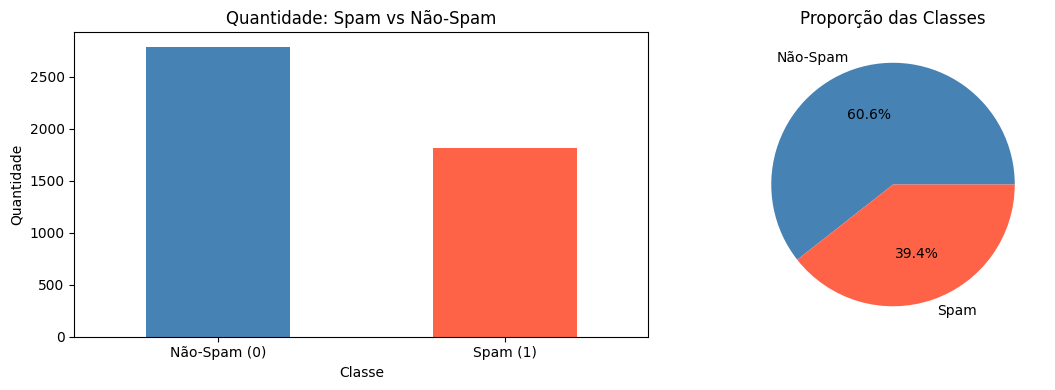

In [6]:
# Distribuição das classes
print("Distribuição das classes:")
print(df['spam'].value_counts())
print(f"\nProporção spam: {df['spam'].mean()*100:.1f}%")
print(f"Proporção não-spam: {(1-df['spam'].mean())*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
df['spam'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Quantidade: Spam vs Não-Spam')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Não-Spam (0)', 'Spam (1)'], rotation=0)

# Gráfico de pizza
df['spam'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Não-Spam', 'Spam'], autopct='%1.1f%%',
    colors=['steelblue', 'tomato'])
axes[1].set_title('Proporção das Classes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


Top 10 features mais correlacionadas com SPAM:
word_freq_your              0.3832
word_freq_000               0.3348
word_freq_remove            0.3321
char_freq_dollar            0.3236
word_freq_you               0.2737
word_freq_free              0.2632
word_freq_business          0.2632
capital_run_length_total    0.2492
word_freq_our               0.2419
char_freq_exclamation       0.2419
Name: spam, dtype: float64


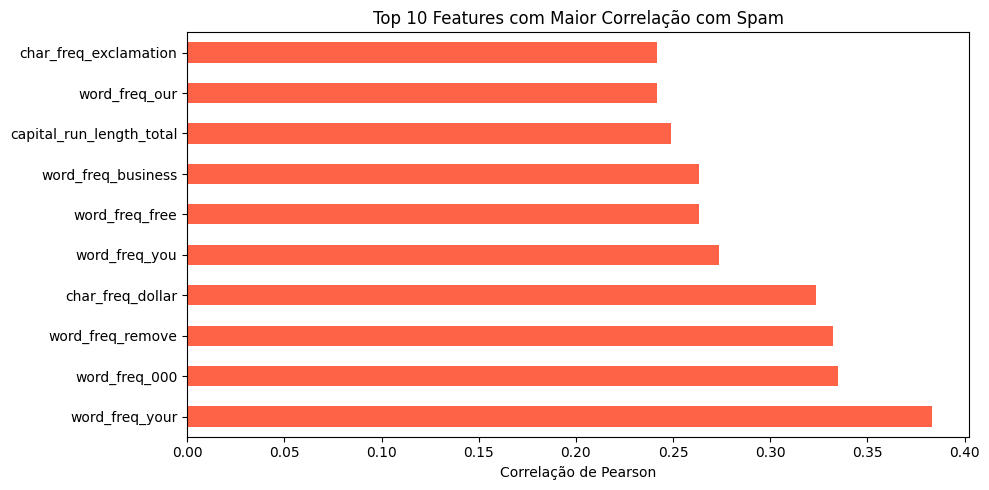

In [7]:
# Top 10 features mais correlacionadas com spam
corr_spam = df.corr()['spam'].drop('spam').sort_values(ascending=False)

print("Top 10 features mais correlacionadas com SPAM:")
print(corr_spam[:10].round(4))

plt.figure(figsize=(10, 5))
corr_spam[:10].plot(kind='barh', color='tomato')
plt.title('Top 10 Features com Maior Correlação com Spam')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()


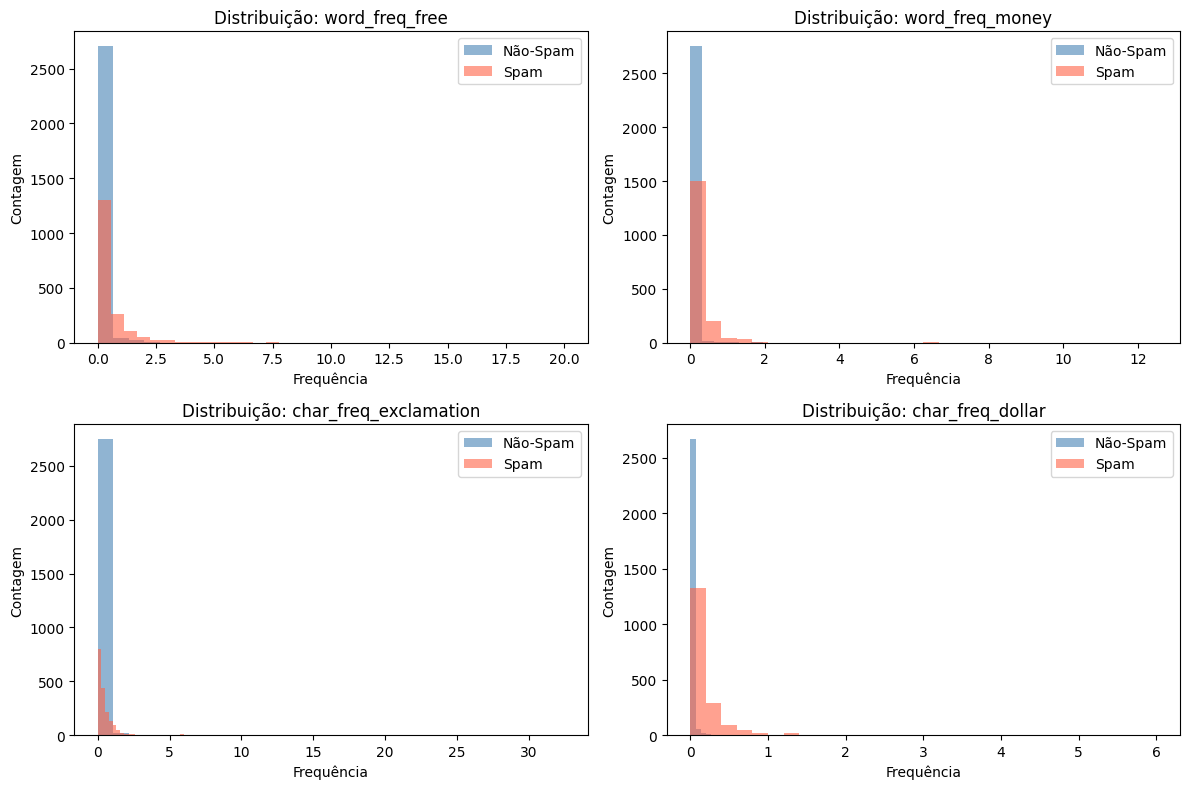

Observação: e-mails spam concentram valores mais altos nessas features.


In [8]:
# Distribuição de 4 features importantes
features_plot = ['word_freq_free', 'word_freq_money', 'char_freq_exclamation', 'char_freq_dollar']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    spam_vals = df[df['spam']==1][feat]
    nospam_vals = df[df['spam']==0][feat]
    axes[i].hist(nospam_vals, bins=30, alpha=0.6, label='Não-Spam', color='steelblue')
    axes[i].hist(spam_vals, bins=30, alpha=0.6, label='Spam', color='tomato')
    axes[i].set_title(f'Distribuição: {feat}')
    axes[i].set_xlabel('Frequência')
    axes[i].set_ylabel('Contagem')
    axes[i].legend()

plt.tight_layout()
plt.show()
print("Observação: e-mails spam concentram valores mais altos nessas features.")


## 5. Separação de Variáveis e Divisão dos Dados

In [9]:
# Separação entre features (X) e variável-alvo (y)
X = df.drop('spam', axis=1)
y = df['spam']

print(f"X (features): {X.shape}")
print(f"y (alvo):     {y.shape}")
print(f"\nVariável-alvo — valores únicos: {y.unique()}")


X (features): (4601, 57)
y (alvo):     (4601,)

Variável-alvo — valores únicos: [1 0]


In [10]:
# Divisão estratificada: 60% treino | 20% validação | 20% teste
# stratify=y garante mesma proporção de spam em todos os conjuntos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_treino, y_treino, test_size=0.25, random_state=42, stratify=y_treino
)

print(f"Treino:    {X_treino.shape[0]} amostras ({X_treino.shape[0]/len(X)*100:.0f}%)")
print(f"Validação: {X_valid.shape[0]} amostras ({X_valid.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:     {X_teste.shape[0]} amostras ({X_teste.shape[0]/len(X)*100:.0f}%)")

print(f"\nProporção spam no treino:    {y_treino.mean()*100:.1f}%")
print(f"Proporção spam na validação: {y_valid.mean()*100:.1f}%")
print(f"Proporção spam no teste:     {y_teste.mean()*100:.1f}%")


Treino:    2760 amostras (60%)
Validação: 920 amostras (20%)
Teste:     921 amostras (20%)

Proporção spam no treino:    39.4%
Proporção spam na validação: 39.3%
Proporção spam no teste:     39.4%


## 6. Normalização dos Dados

O `StandardScaler` é ajustado **apenas no treino** (`fit_transform`) e depois aplicado
nos demais conjuntos (`transform`), evitando data leakage.


In [11]:
scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)   # fit apenas no treino
X_valid_norm  = scaler.transform(X_valid)         # apenas transforma
X_teste_norm  = scaler.transform(X_teste)         # apenas transforma

print(" Normalização concluída (sem data leakage)")
print(f"\nFeature 'word_freq_make':")
print(f"  Antes  → média: {X_treino.iloc[:,0].mean():.4f} | desvio: {X_treino.iloc[:,0].std():.4f}")
print(f"  Depois → média: {X_treino_norm[:,0].mean():.4f} | desvio: {X_treino_norm[:,0].std():.4f}")


✅ Normalização concluída (sem data leakage)

Feature 'word_freq_make':
  Antes  → média: 0.1069 | desvio: 0.3119
  Depois → média: -0.0000 | desvio: 1.0000


## 7. Treinamento e Avaliação dos Modelos na Validação

In [12]:
def avaliar_modelo(modelo, X_tr, X_vl, y_tr, y_vl):
    """Treina o modelo e retorna métricas na validação."""
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_vl)
    prob = modelo.predict_proba(X_vl)[:, 1]

    return {
        'Acurácia':  accuracy_score(y_vl, pred),
        'Precisão':  precision_score(y_vl, pred),
        'Recall':    recall_score(y_vl, pred),
        'F1':        f1_score(y_vl, pred),
        'AUC-ROC':   roc_auc_score(y_vl, prob)
    }

# Modelos avaliados
resultados = {
    'Naive Bayes':         avaliar_modelo(GaussianNB(),
                               X_treino_norm, X_valid_norm, y_treino, y_valid),
    'Reg. Logística':      avaliar_modelo(LogisticRegression(random_state=42, max_iter=1000),
                               X_treino_norm, X_valid_norm, y_treino, y_valid),
    'SVM':                 avaliar_modelo(SVC(probability=True, random_state=42),
                               X_treino_norm, X_valid_norm, y_treino, y_valid),
}

tabela = pd.DataFrame(resultados).T.round(4)
print("TABELA COMPARATIVA — CONJUNTO DE VALIDAÇÃO")
print(tabela.to_string())


TABELA COMPARATIVA — CONJUNTO DE VALIDAÇÃO
                Acurácia  Precisão  Recall      F1  AUC-ROC
Naive Bayes       0.8141    0.6929  0.9475  0.8005   0.9313
Reg. Logística    0.9293    0.9255  0.8923  0.9086   0.9772
SVM               0.9424    0.9531  0.8978  0.9246   0.9793


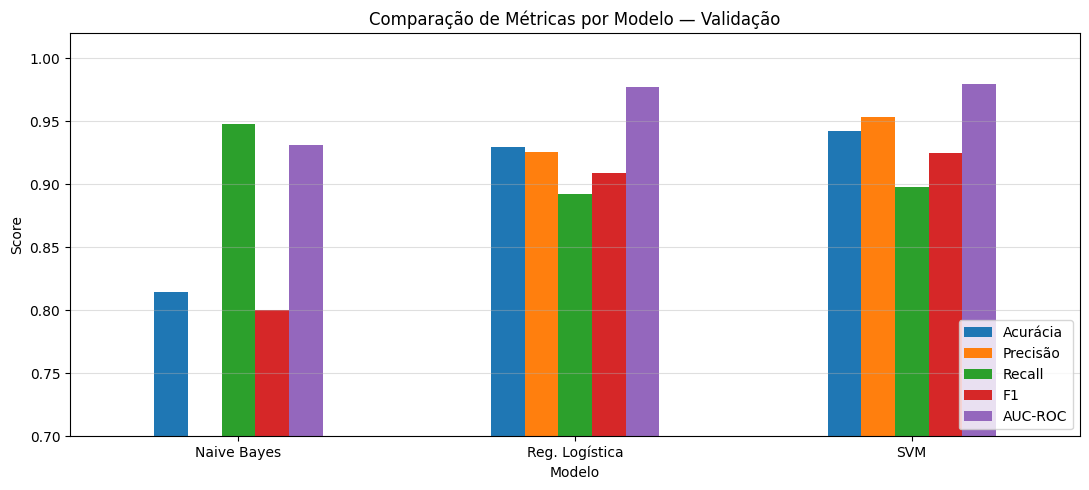

In [13]:
# Visualização comparativa das métricas
fig, ax = plt.subplots(figsize=(11, 5))
tabela.plot(kind='bar', ax=ax)
ax.set_title('Comparação de Métricas por Modelo — Validação')
ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_xticklabels(tabela.index, rotation=0)
ax.set_ylim(0.7, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Validação Cruzada Estratificada (k=5)

Aplicada nos **três modelos** para uma comparação mais robusta e estável.


VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5) — métrica: F1

Naive Bayes          F1: 0.8034 ± 0.0186  | folds: [0.8303 0.8167 0.7842 0.7818 0.804 ]
Reg. Logística       F1: 0.8950 ± 0.0202  | folds: [0.9091 0.8647 0.8818 0.897  0.9224]
SVM                  F1: 0.9062 ± 0.0146  | folds: [0.9227 0.8792 0.9057 0.9129 0.9104]


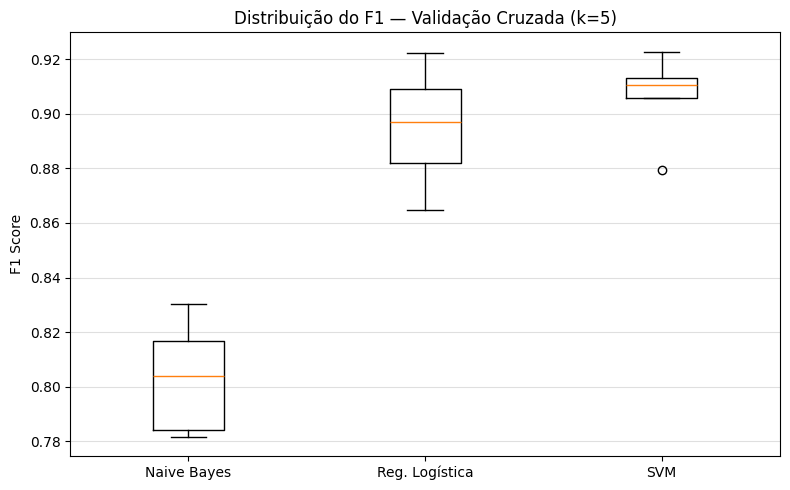

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Naive Bayes':    GaussianNB(),
    'Reg. Logística': LogisticRegression(random_state=42, max_iter=1000),
    'SVM':            SVC(probability=True, random_state=42),
}

print("VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5) — métrica: F1\n")
resultados_cv = {}
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_treino_norm, y_treino,
                             cv=skf, scoring='f1')
    resultados_cv[nome] = scores
    print(f"{nome:<20} F1: {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(4)}")

# Boxplot dos scores por modelo
plt.figure(figsize=(8, 5))
plt.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
plt.title('Distribuição do F1 — Validação Cruzada (k=5)')
plt.ylabel('F1 Score')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## 9. Escolha e Avaliação Final do Melhor Modelo

O **SVM** foi escolhido como modelo final por apresentar os maiores scores de F1 e AUC-ROC
tanto na validação quanto na validação cruzada, demonstrando melhor capacidade de generalização.


In [15]:
# Treina o modelo final no conjunto de treino completo
melhor_modelo = SVC(probability=True, random_state=42)
melhor_modelo.fit(X_treino_norm, y_treino)

pred_teste = melhor_modelo.predict(X_teste_norm)
prob_teste  = melhor_modelo.predict_proba(X_teste_norm)[:, 1]

metricas_finais = {
    'Acurácia':  accuracy_score(y_teste, pred_teste),
    'Precisão':  precision_score(y_teste, pred_teste),
    'Recall':    recall_score(y_teste, pred_teste),
    'F1':        f1_score(y_teste, pred_teste),
    'AUC-ROC':   roc_auc_score(y_teste, prob_teste),
}

print("╔══════════════════════════════════════╗")
print("║   RESULTADO FINAL — CONJUNTO TESTE   ║")
print("╚══════════════════════════════════════╝")
for metrica, valor in metricas_finais.items():
    print(f"  {metrica:<12}: {valor:.4f}")

print("\n", classification_report(y_teste, pred_teste,
      target_names=['Não-Spam', 'Spam']))


╔══════════════════════════════════╗
║   RESULTADO FINAL — CONJUNTO TESTE  ║
╚══════════════════════════════════╝
  Acurácia    : 0.9207
  Precisão    : 0.9191
  Recall      : 0.8760
  F1          : 0.8970
  AUC-ROC     : 0.9654

               precision    recall  f1-score   support

    Não-Spam       0.92      0.95      0.94       558
        Spam       0.92      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



## 10. Gráficos de Avaliação do Modelo Final

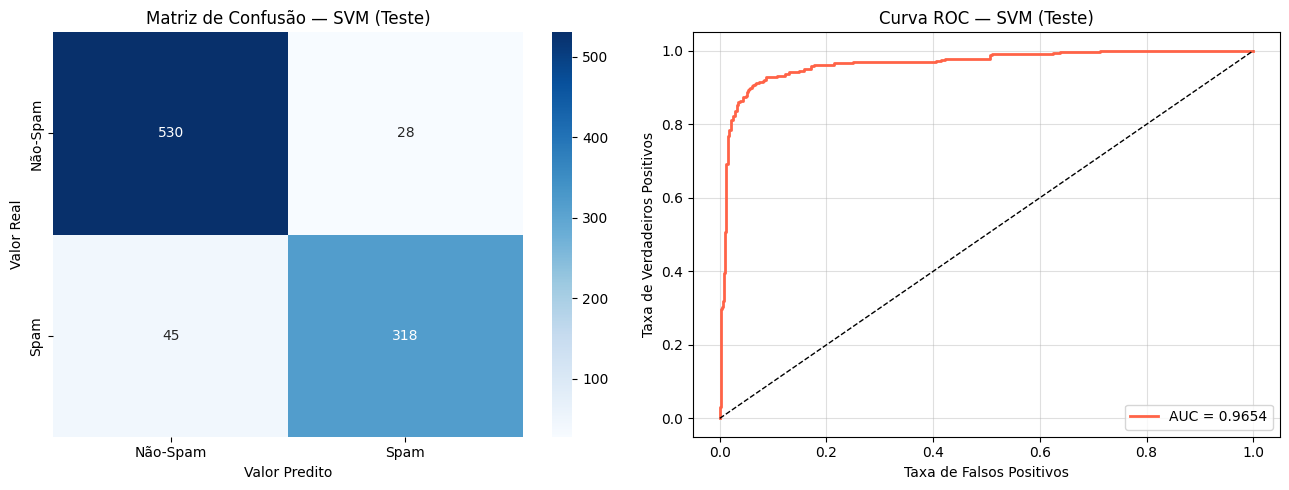

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
cm = confusion_matrix(y_teste, pred_teste)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não-Spam', 'Spam'],
            yticklabels=['Não-Spam', 'Spam'])
axes[0].set_title('Matriz de Confusão — SVM (Teste)')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predito')

# Curva ROC
fpr, tpr, _ = roc_curve(y_teste, prob_teste)
auc_val = roc_auc_score(y_teste, prob_teste)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('Curva ROC — SVM (Teste)')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()


## 11. Análise de Erros

In [17]:
erros_mask = y_teste.values != pred_teste
total_erros = erros_mask.sum()

print(f"Total de erros: {total_erros} ({total_erros/len(y_teste)*100:.1f}% do conjunto de teste)")

# Tipos de erros
cm_vals = confusion_matrix(y_teste, pred_teste)
falsos_pos = cm_vals[0, 1]  # não-spam classificado como spam
falsos_neg = cm_vals[1, 0]  # spam classificado como não-spam

print(f"  Falsos Positivos (não-spam → spam): {falsos_pos}")
print(f"  Falsos Negativos (spam → não-spam): {falsos_neg}")
print(f"\nNo contexto de detecção de spam, Falsos Negativos são mais críticos,")
print(f"pois significam spam que chegou à caixa de entrada do usuário.")


Total de erros: 73 (7.9% do conjunto de teste)
  Falsos Positivos (não-spam → spam): 28
  Falsos Negativos (spam → não-spam): 45

No contexto de detecção de spam, Falsos Negativos são mais críticos,
pois significam spam que chegou à caixa de entrada do usuário.


## 12. Salvamento do Modelo Final

O modelo e o scaler são salvos em formato `.joblib` para serem utilizados pela aplicação Streamlit.


In [18]:
# Salva o modelo e o scaler
joblib.dump(melhor_modelo, 'modelo_final.joblib')
joblib.dump(scaler,        'scaler.joblib')

print("✅ Arquivos salvos:")
print("   modelo_final.joblib  — modelo SVM treinado")
print("   scaler.joblib        — StandardScaler ajustado no treino")

# Teste de carregamento para verificar
modelo_carregado = joblib.load('modelo_final.joblib')
scaler_carregado = joblib.load('scaler.joblib')
pred_check = modelo_carregado.predict(scaler_carregado.transform(X_teste[:3]))
print(f"\n✅ Verificação de carregamento OK — predições: {pred_check}")


✅ Arquivos salvos:
   modelo_final.joblib  — modelo SVM treinado
   scaler.joblib        — StandardScaler ajustado no treino

✅ Verificação de carregamento OK — predições: [1 1 0]


## 13. Conclusão

O projeto desenvolveu um sistema de detecção de e-mails spam utilizando o dataset Spambase (UCI),
com 4.601 amostras e 57 atributos numéricos.

**Resultados obtidos no conjunto de teste (SVM):**
- Os três modelos foram treinados e comparados com métricas de acurácia, precisão, recall, F1 e AUC-ROC.
- A validação cruzada estratificada (k=5) foi aplicada nos três modelos para uma avaliação mais robusta.
- O **SVM** foi escolhido como modelo final por apresentar os melhores resultados em F1 e AUC-ROC.

**Limitações:**
- O dataset é de 1999 e pode não refletir padrões de spam atuais.
- O modelo não analisa o HTML, imagens ou metadados dos e-mails, apenas frequências de palavras e caracteres.

**Trabalhos futuros:**
- Testar modelos baseados em transformers (BERT) para análise semântica do texto.
- Incluir dados mais recentes de spam.
